<h1>Project 4: Cellular Automata</h1>

This project will focus on simulating random walkers and cellular automata in one and two 
dimensions according to randomized values and set rules. 

<H3>Imports</H3>

In [1]:
from vpython import *
import numpy as np
import matplotlib.pyplot as plt

C:\Users\auher\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

<H3>Constants</H3>

## Part 1: Two-Dimensional Random Walker

#### Random Number Generator

Numpy has a random uniform function already for use. Setting a random seed for reporducability and using this function will give us the random values we want. This can be checked for a large number of iterations by inspecting our distribution.

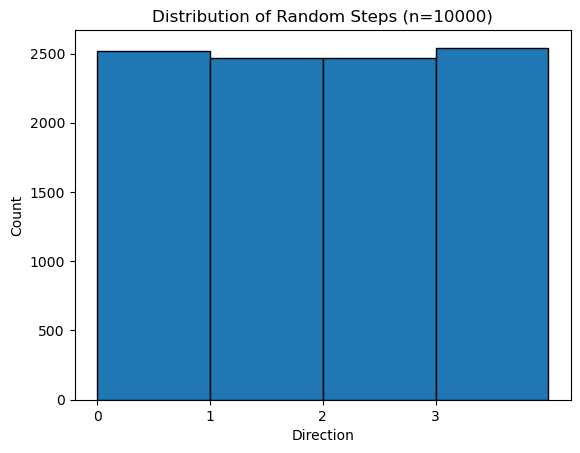

Value 0: 2519 (25.2%)
Value 1: 2471 (24.7%)
Value 2: 2468 (24.7%)
Value 3: 2542 (25.4%)


In [2]:
#Seed for reproducability
np.random.seed(4)

#Number of iterations
num_iter = 10000
dist = []

#For each iteration
for i in range(num_iter):
    #Get a random value for each iteration
    dist.append(np.random.choice(4))
    
#Plot for visual
plt.hist(dist, bins=[0, 1, 2, 3, 4], edgecolor = 'black')
plt.xticks([0, 1, 2, 3])
plt.xlabel('Direction')
plt.ylabel('Count')
plt.title('Distribution of Random Steps (n=10000)')
plt.show()

#Print counts
unique, counts = np.unique(dist, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Value {val}: {count} ({count/num_iter*100:.1f}%)")

Visually, all of the counts look to be very similar. Each value 0-3 here represents one of the four directions. In the statement above, we can see the values all being very close to 1/4 of our total iterations too with percentages of 25.2%, 24.7%, 24.7%, and 25.4%. As we can increase the iterations, we will get closer to an exact uniform distribution, but with 10,000 we have within a 0.3% error, which is acceptable.

#### One Random Walker

In [3]:
#Use 10000 steps
num_iter = 10000
x = 0
y = 0
path_x = []
path_y = []
direction_counts = {0: 0, 1: 0, 2: 0, 3: 0}
moves = [(0, 1), (0, -1), (-1, 0), (1, 0)]

scene = canvas(title="2D Random Walker", width=500, height = 500 )

#One walker sphere that moves
walker = sphere(pos=vector(0, 0, 0), radius=0.3, color=color.blue)

for i in range(num_iter):
    rate(100)
    dx, dy = moves[np.random.choice(4)]

    #Direction counts for each of the four directions
    if dy == 1:   direction_counts[0] += 1
    if dy == -1:  direction_counts[1] += 1
    if dx == -1:  direction_counts[2] += 1
    if dx == 1:   direction_counts[3] += 1

    #Updated position
    x += dx
    y += dy

    #Leave a cylinder at the position to show the trail
    cylinder(pos=vector(x, y, 0), radius=0.3, color=color.cyan)

    #Move the main walker
    walker.pos = vector(x, y, 0)

    path_x.append(x)
    path_y.append(y)

<IPython.core.display.Javascript object>

We can see the cylinder moving in the different directions and randomly. It moves all over the place, but over time, ends up close to where it started due to the normal distribution we are using. <br><br>To verify the movement qualitatively, we can look at the direction counts stored and compare the percentages. We can also look at the path and make sure that the cylinder is not moving diagonally

In [4]:
#Verify uniform distribution
for d, count in direction_counts.items():
    print(f"Direction {d}: {count} ({count/num_iter*100:.1f}%)")

#Verify no diagonal movement
for i in range(1, len(path_x)):
    dx = abs(path_x[i] - path_x[i-1])
    dy = abs(path_y[i] - path_y[i-1])
    if dx + dy != 1:
        print(f"Invalid move at step {i}!")
        break
else:
    print("All moves valid — no diagonal moves detected")

Direction 0: 2537 (25.4%)
Direction 1: 2537 (25.4%)
Direction 2: 2485 (24.9%)
Direction 3: 2441 (24.4%)
All moves valid — no diagonal moves detected


We can see that after checking the direction counts, all were within 0.4% of our expected value of 25%. We also do not get any invalid moves found from our path, indicating that the directions were followed.

#### Verifying with many walkers

Function for many runs of the walker to return the distance, no visualization

In [5]:
#Function to get the distance from the origin for a walker where iterations is passed in
def random_walker(num_steps):
    x, y = 0, 0
    #For each step, update the current position
    for _ in range(num_steps):
        dx, dy = moves[np.random.choice(4)]
        x += dx
        y += dy
    #Return the distance, pythagorean used
    return np.sqrt(x**2 + y**2)

N =   100, Expected: 10.0000, Avg: 8.9685, Diff: 10.3153%
N =  1000, Expected: 31.6228, Avg: 27.4440, Diff: 13.2146%
N = 10000, Expected: 100.0000, Avg: 88.4668, Diff: 11.5332%


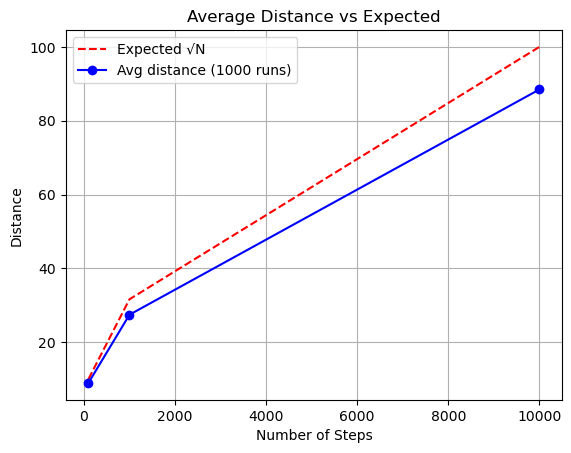

In [6]:
#Number of walkers averaged for each run
num_walkers = 1000
#Different amounts of iterations to use
num_iters = [100, 1000, 10000]
avg_distances = []
expected_distances = []

#For all iterations
for num_steps in num_iters:
    #Run walker function as many times as specified
    distances = [random_walker(num_steps) for _ in range(num_walkers)]
    #AVergae from all runs
    avg = np.mean(distances)
    #Expected = sqrt(N)
    expected = np.sqrt(num_steps)
    avg_distances.append(avg)
    expected_distances.append(expected)
    print(f"N ={num_steps:>6}, Expected: {expected:.4f}, Avg: {avg:.4f}, Diff: {(abs(avg-expected)/expected)*100:.4f}%")

#Plot
plt.plot(num_iters, expected_distances, 'r--', label='Expected √N')
plt.plot(num_iters, avg_distances, 'bo-', label=f'Avg distance ({num_walkers} runs)')
plt.xlabel('Number of Steps')
plt.ylabel('Distance')
plt.title('Average Distance vs Expected')
plt.legend()
plt.grid(True)
plt.show()


As is seen in this plot and from print statements, we can see that the calculated average distance is close to the theoretical expected value of square root of number of steps. The difference in each ranges from 10.3% to 13.2%, showing a significant but not very large difference. This still helps to validate our model. 

## Part 2: Two-State 1-D Cellular Automaton

I am choosing to use rule 57. Examining the different rules, 57 has a very unique and cool output. It represents a pyramid with shading. It is fairly simple to produce but still complex enough to capture the behavior of an automaton

In [7]:
#From wolfram, an algebraic representation where p, q, and r are left, center, and right respectively
#https://atlas.wolfram.com/01/01/57/01_01_1_57.html
def rule57(p, q, r):
    return (1 + q + r + p * r) % 2

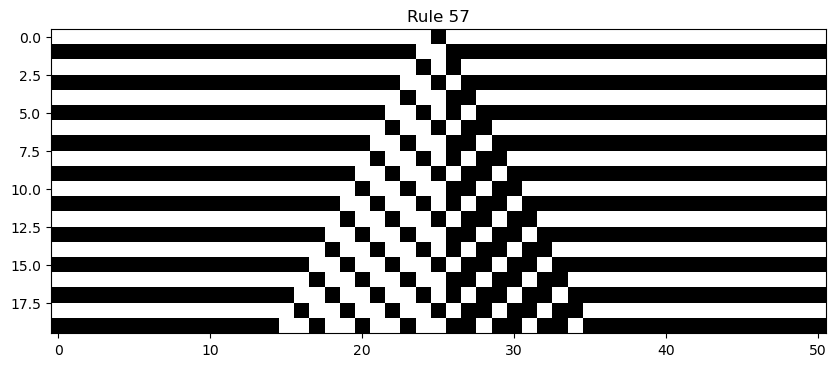

In [8]:
#Width and number of steps to use
width = 51
steps = 20

#Starting position, one in center used
grid = np.zeros((steps, width), dtype=int)
grid[0, width // 2] = 1

#Update loop
#For every row
for t in range(1, steps):
    #0 based indexing
    row = grid[t - 1]
    #For every column
    for i in range(width):
        #Left bit
        p = row[(i - 1) % width]
        #Middle bit
        q = row[i]
        #Right bit
        r = row[(i + 1) % width]
        #Update next row with our algebraic rule
        grid[t, i] = rule57(p, q, r)

#Plot
plt.figure(figsize=(10, 6))
plt.imshow(grid, cmap="binary")
plt.title("Rule 57")
plt.show()

The stopping condition here is simply to go for a certain number of steps, 20 was chosen as a sufficient number to visualize the pattern and compare it to the expected image to confirm the correct behavior. Each row is an increase in time and shows the progression.

## Part 3: Conway's Game of Life

The game of life is to be simulated and validated for the different types of patterns that we could encounter

#### Behavior Function

In [9]:
#For every unit of time passing
def life_step(grid):
    #Number of neighbors grid of same shape
    neighbors = np.zeros(grid.shape, dtype=int)
    #Check for all left and right, up and down cells
    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            #Skip over cell itself, only want neighbors
            if i == 0 and j == 0:
                continue
            #For toroidal grids as specified
            neighbors += np.roll(np.roll(grid, i, axis=0), j, axis=1)
    
    #Life/survive condition
    #Alive with two or three numbers, dead with three neighbors
    life = (neighbors == 3) | ((grid == 1) & (neighbors == 2))
    
    return life.astype(int)
    

#### Still Lifes

True


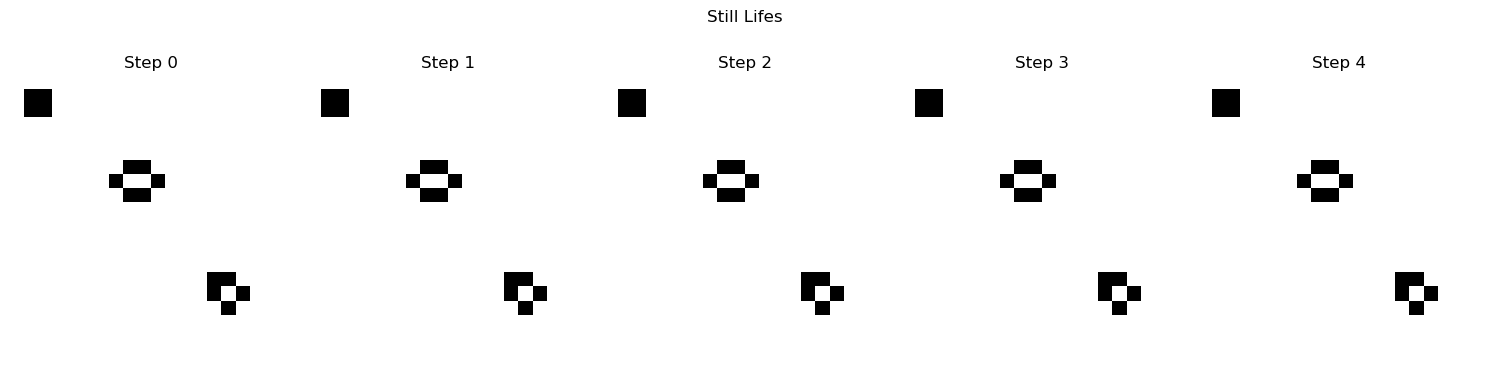

In [10]:
#Initialize all values to 0 in grid,
#20 x 20 here
grid = np.zeros((20, 20), dtype=int)
#Capture full behavior
steps = 4

#Add a block
grid[1:3, 1:3] = 1

#Add a beehive
grid[7, 7] = 1
grid[6, 8:10] = 1
grid[8, 8:10] = 1
grid[7, 10] = 1

#Add a boat
grid[14, 14:16] = 1
grid[15, 14] = 1
grid[15, 16] = 1
grid[16, 15] = 1
    
#Save intial state
grid_initial = grid.copy()

#Run through specified amount of steps
snapshots = [grid_initial]
for _ in range(steps):
    #Synchronous update
    grid = life_step(grid)
    #Add specific step
    snapshots.append(grid.copy())

#Verify
print(np.array_equal(grid_initial, snapshots[-1]))

#Output visual
fig, axes = plt.subplots(1, len(snapshots), figsize=(15, 4))

for t, ax in enumerate(axes):
    ax.imshow(snapshots[t], cmap="binary")
    ax.set_title(f"Step {t}")
    ax.axis("off")

plt.suptitle("Still Lifes")
plt.tight_layout()
plt.show()

As we can see from the print statement, the first and last frames are equal, as expected. We can also see all three of the different patterns do not change which is the expected behavior for a still life

#### Oscillators

Step 0 == Step 2: True
Step 0 == Step 4: True
Step 0 == Step 6: True


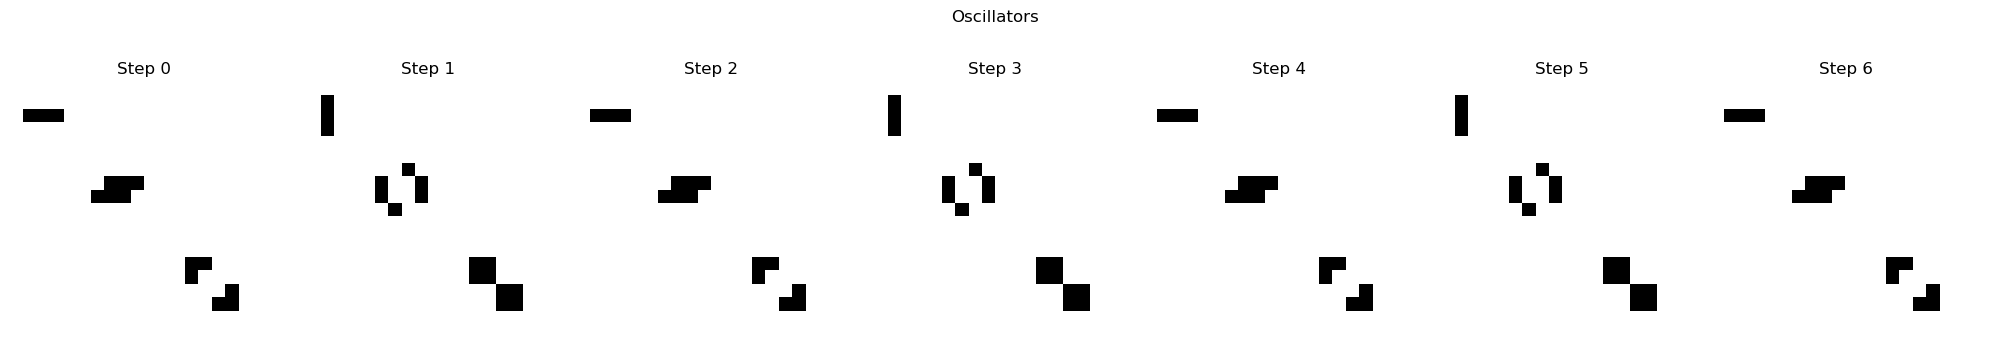

In [11]:
#Initialize all values to 0 in grid
#20 x 20 here
grid = np.zeros((20, 20), dtype=int)
#3 full cycles for oscillators
steps = 6

#Blinker
grid[2, 1:4] = 1

#Toad
grid[7, 7:10] = 1
grid[8, 6:9] = 1

#Beacon
grid[13, 13:15] = 1
grid[14, 13] = 1
grid[15, 16] = 1
grid[16, 15:17] = 1

#Initial state
grid_initial = grid.copy()

#Run through specified amount of steps
snapshots = [grid_initial]
for _ in range(steps):
    #Synchronous update
    grid = life_step(grid)
    #Add specific step
    snapshots.append(grid.copy())

#Verify period of 2 cycles
print("Step 0 == Step 2:", np.array_equal(snapshots[0], snapshots[2]))
print("Step 0 == Step 4:", np.array_equal(snapshots[0], snapshots[4]))
print("Step 0 == Step 6:", np.array_equal(snapshots[0], snapshots[6]))

#Output visual
fig, axes = plt.subplots(1, len(snapshots), figsize=(20, 4))
for t, ax in enumerate(axes):
    ax.imshow(snapshots[t], cmap="binary")
    ax.set_title(f"Step {t}")
    ax.axis("off")
plt.suptitle("Oscillators")
plt.tight_layout()
plt.show()

From the print statements, the oscillaitions are shown as each of these oscillations ahve a cycle of 2 and the grids are equal for every 2 step increase. Visually, each of the patterns changes every cycle and continues to do so for all of the 6 cycles. The blinker, toad, and beacon all behave as they should and we can verify this group.

#### Spaceship

One glider will be used to test for thespaceship patterns, as the easiest and simplest glider

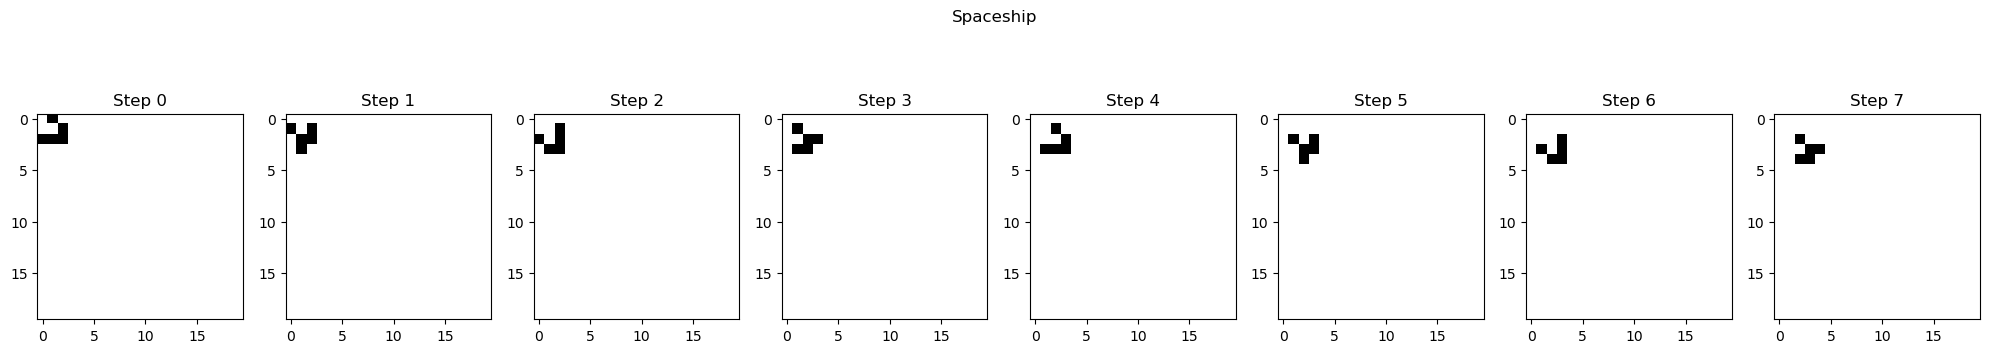

In [12]:
#Initialize all values to 0 in grid
#20 x 20 here
grid = np.zeros((20, 20), dtype=int)
#3 full cycles for oscillators
steps = 7

#Glider
grid[0, 1] = 1
grid[1, 2] = 1
grid[2, 0:3] = 1

#Initial state
grid_initial = grid.copy()

#Run through specified amount of steps
snapshots = [grid_initial]
for _ in range(steps):
    #Synchronous update
    grid = life_step(grid)
    #Add specific step
    snapshots.append(grid.copy())

#Output visual
fig, axes = plt.subplots(1, len(snapshots), figsize=(20, 4))
for t, ax in enumerate(axes):
    ax.imshow(snapshots[t], cmap="binary")
    ax.set_title(f"Step {t}")
plt.suptitle("Spaceship")
plt.tight_layout()
plt.show()

This glider pattern can be verified visually. With a period of 4 cycles, we can see the glider returnto its starting position at steps 0 and 3. Using the axis values, we can see the glider also moving down and right as it oscillates

## Part 4: Conway's Game of Life with Asynchronous Updating

To analyze the effect of asynchronous updating, I am using cyclic updating. Cyclic is easiest to reproduce as there is no randomness involved and the results can be easily verified. The implementationis also very similar to my synchronous method, and will allow for easier debugging and verifying. This code is cyclic as we go through everycell in the grid from left to right and up to down. We are updating values every time, and future cells may be using updated cells to determine its value

In [13]:
#For every unit of time passing
def life_step_async(grid):
    grid = grid.copy()
    #For each row
    for i in range(grid.shape[0]):
        #For each column
        for j in range(grid.shape[1]):
            #Neighbor count
            neighbors = 0
            #All surrounding directions
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    #Skip cell itself
                    if di == 0 and dj == 0:
                        continue
                    #Handles wrapping    
                    neighbors += grid[(i + di) % grid.shape[0], (j + dj) % grid.shape[1]]
            
            #Apply Game of Life rules to this single cell immediately
            #Survival or death
            if grid[i, j] == 1:
                #Enough to survive
                if (neighbors == 2) or (neighbors == 3):
                    grid[i, j] = 1
                #Over/under populated
                else:
                    grid[i, j] = 0
            #Birth or remaining dead
            else:
                #Birth
                if neighbors == 3:
                    grid[i, j] = 1
                #Still dead
                else:
                    grid[i, j] = 0    
    return grid

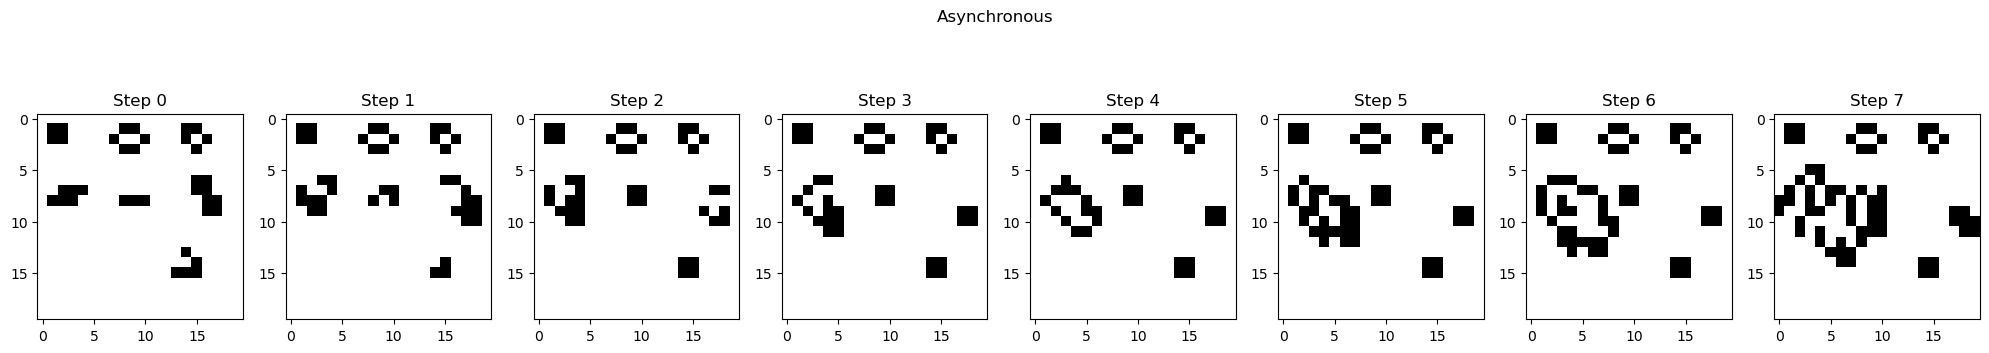

In [14]:
#Initialize all values to 0 in grid
#20 x 20 here
grid = np.zeros((20, 20), dtype=int)
#3 full cycles for oscillators
steps = 7

#Still lifes
#Block
grid[1:3, 1:3] = 1

#Beehive
grid[1, 8:10] = 1
grid[2, 7] = 1
grid[2, 10] = 1
grid[3, 8:10] = 1

#Boat
grid[1, 14:16] = 1
grid[2, 14] = 1
grid[2, 16] = 1
grid[3, 15] = 1

#Oscillators
#Blinker
grid[8, 8:11] = 1

#Toad
grid[7, 2:5] = 1
grid[8, 1:4] = 1

#Beacon
grid[6, 15:17] = 1
grid[7, 15:17] = 1
grid[8, 16:18] = 1
grid[9, 16:18] = 1

# Spaceship - Glider (bottom left)
grid[13, 14] = 1
grid[14, 15] = 1
grid[15, 13:16] = 1
#Initial state
grid_initial = grid.copy()

#Run through specified amount of steps
snapshots = [grid_initial]
for _ in range(steps):
    #Aynchronous update
    grid = life_step_async(grid)
    #Add specific step
    snapshots.append(grid.copy())

#Output visual
fig, axes = plt.subplots(1, len(snapshots), figsize=(20, 4))
for t, ax in enumerate(axes):
    ax.imshow(snapshots[t], cmap="binary")
    ax.set_title(f"Step {t}")
plt.suptitle("Asynchronous")
plt.tight_layout()
plt.show()

We can see that with all of the same patterns implemented and observed previously, aynchronous updating provides a very different result. Looking at the still lifes, the block remains as a still life, but both the beehive and boat disappear after just two cycles, where they both were unchanged with synchronous updates. In the next lowest set of figures, the osicllators are expected to oscillate and return to their previous state. With asynchronous updates, the blinker turns into a still life while the toad and beacon both disappear after two cycles. Lastly, the spaceship used, the glider, disappears after just one step.<br><br>These two versions operate very differently, and to get our expected behavior, synchronous must be used. Any version of asynchronous may produce a unique output but would still not be reliable or accurate to be used in the game of life